In [17]:
import sys
sys.path.append("../../src/")
import numerical_quenches as nq
import TFIM_operators_from_states as op
import kibble_zurek as kz
from project_imports import *



Theere are basically three types of return probabilities:

$$\braket{\psi_0|\psi(\tau)}= \text{Quench RP}$$
$$\braket{\psi_0|\psi(\tau+t)}= \text{Full RP}$$
$$\braket{\psi(\tau)|\psi(\tau+t)} = \text{Free RP}$$

In [77]:
#Calculating Quench RP

# We can actually do this analytically.

taus = logspace(-5,3,400)
tau=100
L=300
state_0 = kz.state(L,tau,-10000*tau)
states = [kz.state(L,tau,tau) for tau in tqdm(taus)]

100%|██████████| 400/400 [04:20<00:00,  1.54it/s]


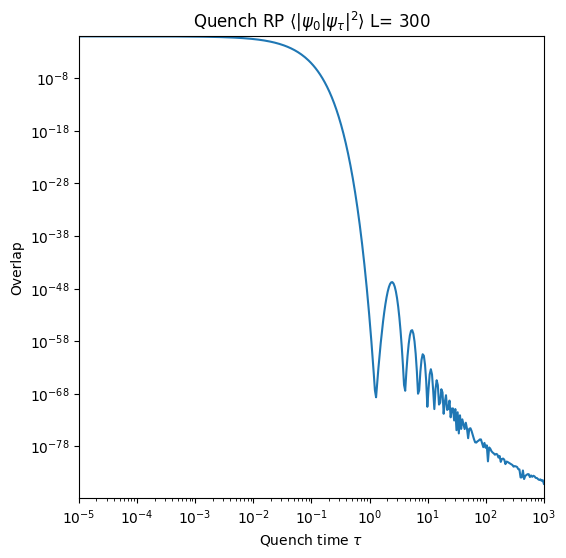

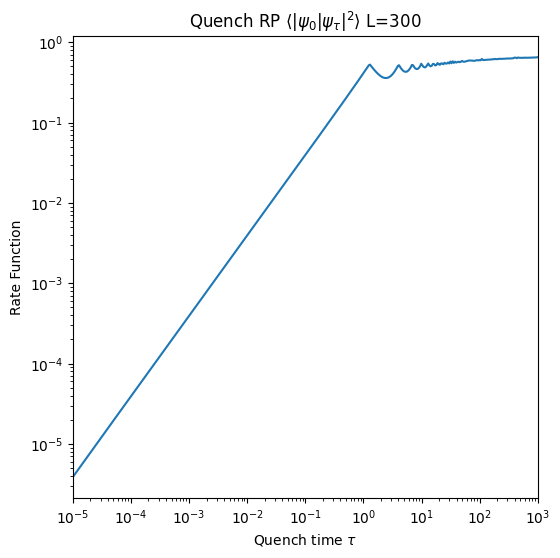

In [96]:
plt.figure(figsize=(6,6))
plot(taus,nq.overlap(states,state_0))
ylim(2**(-L)*2**(8),1+.1)
xlim(taus[0],taus[-1])
xscale("log")
yscale("log")
title(r"Quench RP $\langle |\psi_0 | \psi_\tau|^2 \rangle$" + f" L= {L}")
xlabel(r"Quench time $\tau$")
ylabel("Overlap")
show()
plt.figure(figsize=(6,6))

plot(taus,-log(nq.overlap(states,state_0))/L)
#plt.hlines(2*2**(-L),taus[0],taus[-1])
#ylim(2**(-L),1)
xlim(taus[0],taus[-1])
#plot(taus,taus**(-2)/1000000000000000000)
xscale("log")
yscale("log")
title(r"Quench RP $\langle |\psi_0 | \psi_\tau|^2 \rangle$"+f" L={L}")
xlabel(r"Quench time $\tau$")
ylabel("Rate Function")
show()

In [173]:
def g_free(t,args):
    gf=args
    return gf

In [172]:
nq.g_linear_hold(-tau,args)

2.0

In [185]:
#Full RP and Free RP we can kind of do together.
g0=5
L= 500

psi0 = nq.groundstate(g0,L)
tau= 10

args=(tau,tau)

gf= nq.g_linear_hold(tau,args)
print(gf)
args2=(gf)

t_eval= np.linspace(-(g0-1)*tau,tau,1000)

psi_t= nq.states(L,t_eval,nq.g_linear_hold,args)

t_eval2= np.linspace(tau+.000001,tau+10*pi,1000)
psi_t_free= nq.states(L,t_eval2,g_free,args2,psi_t[-1])

QuenchRP= nq.overlap(psi_t,psi0)**2
FullRP = nq.overlap(psi_t_free,psi0)**2
FreeRP = nq.overlap(psi_t_free,psi_t_free[0])**2


0.0
g0=5.0
g0=0.0


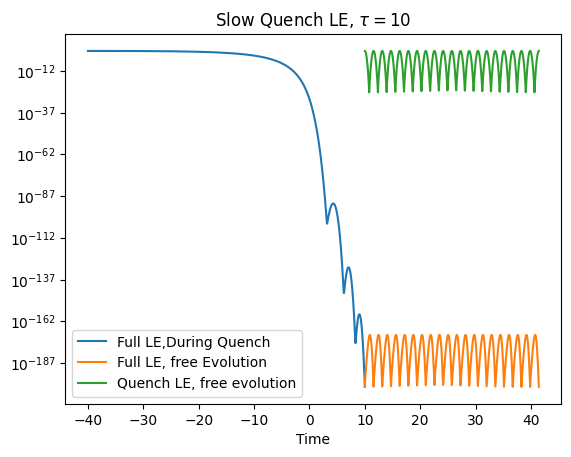

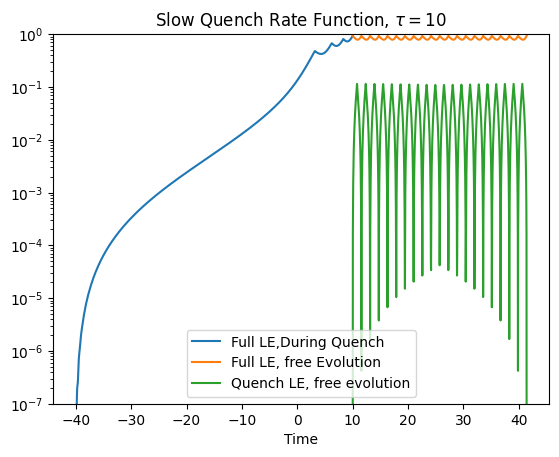

In [193]:
plot(t_eval,QuenchRP,label="Full LE,During Quench")
plot(t_eval2,FullRP,label="Full LE, free Evolution")
plot(t_eval2,FreeRP,label="Quench LE, free evolution")
yscale("log")
#xscale("log")
xlabel("Time")
title(rf"Slow Quench LE, $\tau={tau}$")
legend()
show()

plot(t_eval,-log(QuenchRP)/L,label="Full LE,During Quench")
plot(t_eval2,-log(FullRP)/L,label="Full LE, free Evolution")
plot(t_eval2,-log(FreeRP)/L,label="Quench LE, free evolution")
title(rf"Slow Quench Rate Function, $\tau={tau}$")
yscale("log")
#xscale("log")
xlabel("Time")
ylim(10e-8,1)
legend()
show()

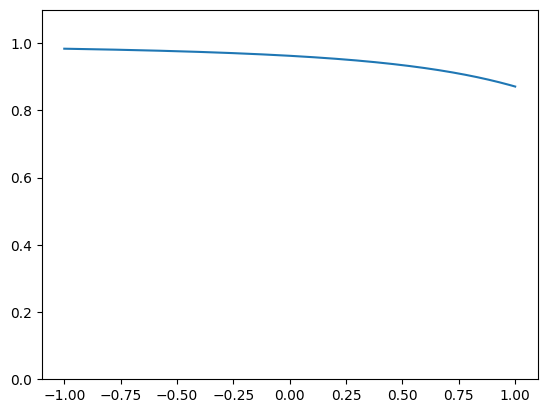

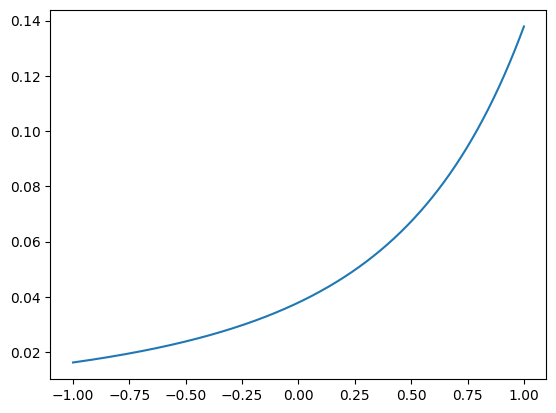

In [253]:
tau=1
t =np.linspace(-tau,tau,1000)
A= [np.abs(kz.v_tilde(tau,pi/4,ti))**2 for ti in t]
neglog = [ -mp.log(x) for x in A ]

plot(t,A)
ylim(0,1.1)
show()
plot(t,neglog)

show()

In [ ]:
import mpmath as mp

dat = A # the mpf array

neglog = [ -mp.log(A)/L for x in dat ]
plot(t,neglog)

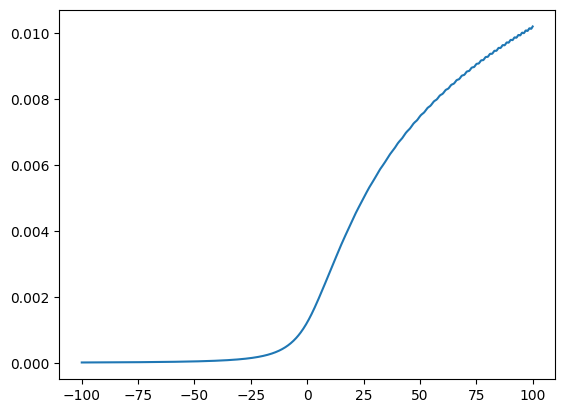